In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
df_steam = pd.read_csv('steam.csv')
df_steam.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [3]:
df_steam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

In [4]:
# Filtrando apenas jogos que tem 'Indie' na coluna de gêneros
df_indie = df_steam[df_steam['genres'].str.contains('Indie', na=False)].copy()

# Selecionando apenas as colunas úteis para a análise
colunas_uteis = ['name', 'release_date', 'developer', 'platforms', 'genres', 
                 'positive_ratings', 'negative_ratings', 'average_playtime', 'price']
df_limpo = df_indie[colunas_uteis].copy()

# Criando a métrica de sucesso: Taxa de Aprovação
df_limpo['total_ratings'] = df_limpo['positive_ratings'] + df_limpo['negative_ratings']

# Calculo da porcentagem 
df_limpo['taxa_aprovacao'] = (df_limpo['positive_ratings'] / df_limpo['total_ratings']) * 100

# Removendo os jogos que não tiveram nenhuma avaliação (para evitar divisão por zero)
df_limpo = df_limpo.dropna(subset=['taxa_aprovacao'])

# Mostrar o resultado
print(f"Total de jogos Indie analisados: {len(df_limpo)}")
df_limpo[['name', 'price', 'total_ratings', 'taxa_aprovacao']].head()

Total de jogos Indie analisados: 19421


,name,price,total_ratings,taxa_aprovacao
26,Rag Doll Kung Fu,5.99,57,70.175439
30,Darwinia,7.19,630,74.920635
31,Uplink,6.99,1754,91.334094
32,DEFCON,7.19,2401,85.672636
33,Multiwinia,7.19,443,83.069977


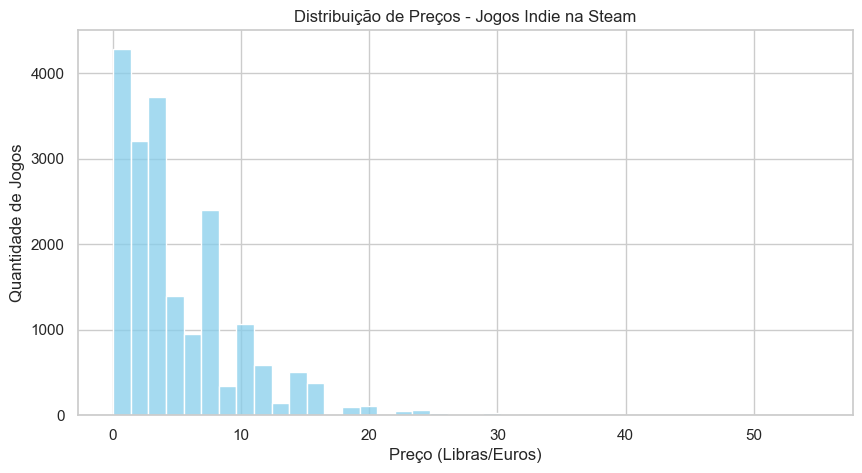

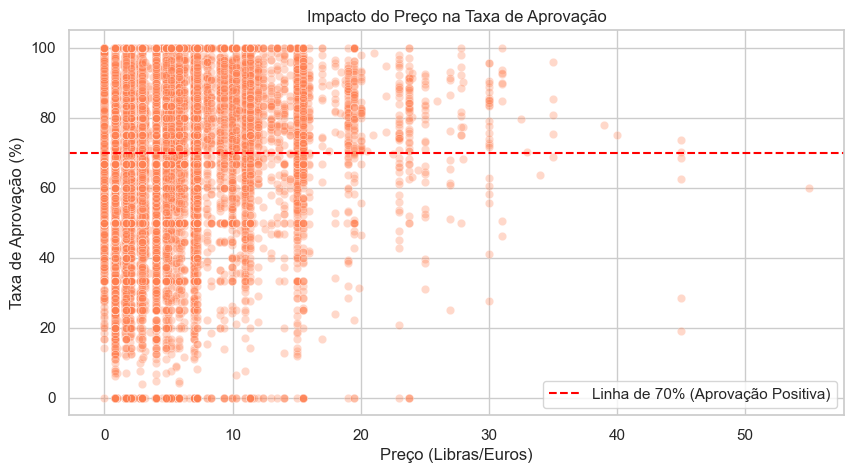

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual
sns.set_theme(style="whitegrid")

# Removendo os jogos com preços absurdos (outliers maiores que 60) para não distorcer o gráfico
df_graficos = df_limpo[df_limpo['price'] <= 60].copy()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_graficos, x='price', bins=40, color='skyblue')
plt.title('Distribuição de Preços - Jogos Indie na Steam')
plt.xlabel('Preço (Libras/Euros)')
plt.ylabel('Quantidade de Jogos')
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_graficos, x='price', y='taxa_aprovacao', alpha=0.3, color='coral')
plt.title('Impacto do Preço na Taxa de Aprovação')
plt.xlabel('Preço (Libras/Euros)')
plt.ylabel('Taxa de Aprovação (%)')
plt.axhline(y=70, color='red', linestyle='--', label='Linha de 70% (Aprovação Positiva)')
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

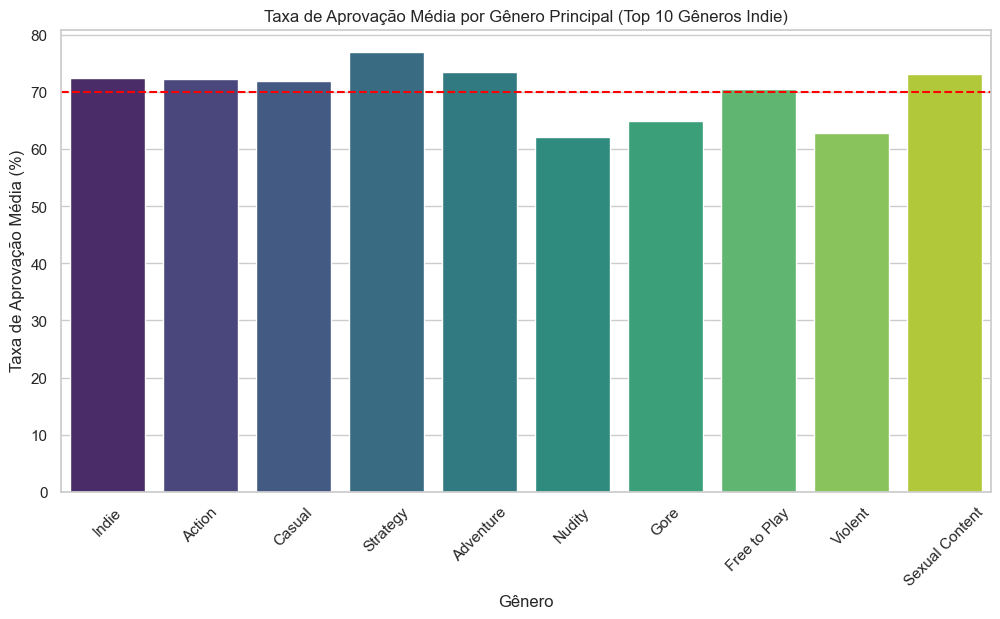

In [6]:
# Recriando o dataframe com a garantia de que a coluna 'genres' está lá
df_graficos = df_indie[df_indie['price'] <= 60].copy()
df_graficos['total_ratings'] = df_graficos['positive_ratings'] + df_graficos['negative_ratings']
df_graficos['taxa_aprovacao'] = (df_graficos['positive_ratings'] / df_graficos['total_ratings']) * 100
df_graficos = df_graficos.dropna(subset=['taxa_aprovacao'])

# Criando a coluna do gênero principal
df_graficos['main_genre'] = df_graficos['genres'].apply(lambda x: str(x).split(';')[0])

#  Descobrindo os top 10 gêneros
top_10_generos = df_graficos['main_genre'].value_counts().head(10).index
df_top_generos = df_graficos[df_graficos['main_genre'].isin(top_10_generos)]

# Gerando o Gráfico 3
plt.figure(figsize=(12, 6))
#  Gerando o Gráfico 3 (Sem o aviso do FutureWarning)
plt.figure(figsize=(12, 6))

sns.barplot(data=df_top_generos, x='main_genre', y='taxa_aprovacao', hue='main_genre', palette='viridis', errorbar=None, legend=False)

plt.title('Taxa de Aprovação Média por Gênero Principal (Top 10 Gêneros Indie)')
plt.xlabel('Gênero')
plt.ylabel('Taxa de Aprovação Média (%)')
plt.xticks(rotation=45)
plt.axhline(y=70, color='red', linestyle='--', label='Linha de 70% (Aprovação)')
plt.show()

In [7]:
# Copia da base limpa
df_ml = df_limpo.copy()

df_ml['english'] = df_indie['english']

# Isolando o genero principal 
df_ml['main_genre'] = df_ml['genres'].apply(lambda x: str(x).split(';')[0])

# Convertendo os generos de texto para colunas nueéricas 
df_dummies = pd.get_dummies(df_ml['main_genre'], prefix='genre', dtype=int)

# Juntamos as novas colunas de volta a tabela principal
df_ml = pd.concat([df_ml, df_dummies], axis=1)

# Criamos a coluna 'is_rpg' (1 se tiver RPG em qualquer lugar do genero, 0 se nao)
df_ml['is_rpg'] = df_ml['genres'].str.contains('RPG').astype(int)

# Visualização da tabela
colunas_para_mostrar = ['name', 'price', 'taxa_aprovacao', 'english', 'is_rpg', 'genre_Action', 'genre_RPG']
print("Pré-visualização dos dados numéricos para a Máquina:")
df_ml[colunas_para_mostrar].head()

Pré-visualização dos dados numéricos para a Máquina:


,name,price,taxa_aprovacao,english,is_rpg,genre_Action,genre_RPG
26,Rag Doll Kung Fu,5.99,70.175439,1,0,0,0
30,Darwinia,7.19,74.920635,1,0,0,0
31,Uplink,6.99,91.334094,1,0,0,0
32,DEFCON,7.19,85.672636,1,0,0,0
33,Multiwinia,7.19,83.069977,1,0,0,0


In [8]:
import scipy.stats as stats

print("--- RESULTADOS DOS TESTES DE HIPÓTESE ---\n")

# Teste 1 - Impacto do Idioma 
# Separamos as notas dos jogos EM inglês e dos jogos NÃO EM inglês
notas_com_ingles = df_ml[df_ml['english'] == 1]['taxa_aprovacao']
notas_sem_ingles = df_ml[df_ml['english'] == 0]['taxa_aprovacao']

# Executando o Teste 
t_stat_lang, p_valor_lang = stats.ttest_ind(notas_com_ingles, notas_sem_ingles, equal_var=False)

print(f"Média de Aprovação (Com Inglês): {notas_com_ingles.mean():.2f}%")
print(f"Média de Aprovação (Sem Inglês): {notas_sem_ingles.mean():.2f}%")
print(f"P-Valor (Idioma): {p_valor_lang:.5f}")

if p_valor_lang < 0.05:
    print("-> CONCLUSÃO: O suporte ao inglês impacta significativamente as notas (Diferença não é acaso).\n")
else:
    print("-> CONCLUSÃO: A diferença de notas entre ter ou não inglês não é estatisticamente significativa.\n")

# Teste 2 - Impacto do Gênero (RPG)
# Separamos as notas dos jogos RPG e dos jogos NÃO RPG
notas_com_rpg = df_ml[df_ml['is_rpg'] == 1]['taxa_aprovacao']
notas_sem_rpg = df_ml[df_ml['is_rpg'] == 0]['taxa_aprovacao']

# Executando o Teste 
t_stat_rpg, p_valor_rpg = stats.ttest_ind(notas_com_rpg, notas_sem_rpg, equal_var=False)

print(f"Média de Aprovação (RPG): {notas_com_rpg.mean():.2f}%")
print(f"Média de Aprovação (Não RPG): {notas_sem_rpg.mean():.2f}%")
print(f"P-Valor (RPG): {p_valor_rpg:.5f}")

if p_valor_rpg < 0.05:
    print("-> CONCLUSÃO: Ser um RPG impacta significativamente as notas.\n")
else:
    print("-> CONCLUSÃO: A diferença de notas não é estatisticamente significativa.\n")

--- RESULTADOS DOS TESTES DE HIPÓTESE ---

Média de Aprovação (Com Inglês): 72.08%
Média de Aprovação (Sem Inglês): 76.15%
P-Valor (Idioma): 0.00188
-> CONCLUSÃO: O suporte ao inglês impacta significativamente as notas (Diferença não é acaso).

Média de Aprovação (RPG): 71.86%
Média de Aprovação (Não RPG): 72.20%
P-Valor (RPG): 0.41581
-> CONCLUSÃO: A diferença de notas não é estatisticamente significativa.



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

print("A preparar os dados para o modelo preditivo...")

# Define as variaveis de entrada (X) e a variável alvo (y)
# Juntamos as colunas básicas com todas as colunas de género (0 e 1)
colunas_features = ['price', 'english', 'is_rpg'] + list(df_dummies.columns)

X = df_ml[colunas_features]
y = df_ml['taxa_aprovacao']

# Dividimos a base de dados 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Quantidade de jogos para a máquina aprender (Treino): {len(X_train)}")
print(f"Quantidade de jogos escondidos para a prova (Teste): {len(X_test)}")

# Cria e treina o Algoritmo
print("\nA treinar a Inteligência Artificial (isto pode demorar alguns segundos)...")
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# IA estuda os dados
modelo_rf.fit(X_train, y_train)

print("Treino concluído com sucesso! A IA já encontrou os padrões de mercado.")

A preparar os dados para o modelo preditivo...
Quantidade de jogos para a máquina aprender (Treino): 15536
Quantidade de jogos escondidos para a prova (Teste): 3885

A treinar a Inteligência Artificial (isto pode demorar alguns segundos)...
Treino concluído com sucesso! A IA já encontrou os padrões de mercado.


A testar a Inteligência Artificial com dados ocultos...

-> Erro Absoluto Médio (MAE): 18.00%
Isto significa que, em média, a IA erra a previsão da nota de um jogo em apenas 18.00 pontos percentuais.



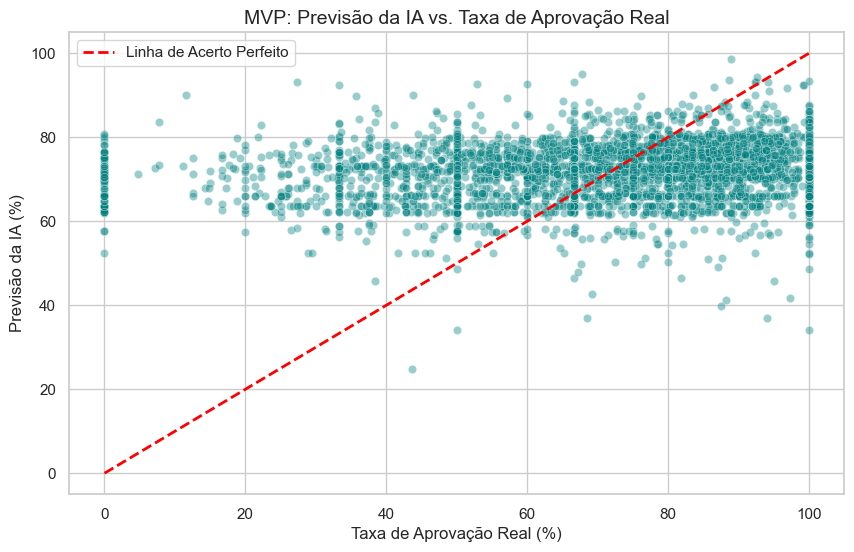

In [10]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

print("A testar a Inteligência Artificial com dados ocultos...\n")

# Previsoes na base de teste
previsoes = modelo_rf.predict(X_test)

# Calcula o Erro Absoluto Médio (MAE)
erro_mae = mean_absolute_error(y_test, previsoes)

print(f"-> Erro Absoluto Médio (MAE): {erro_mae:.2f}%")
print(f"Isto significa que, em média, a IA erra a previsão da nota de um jogo em apenas {erro_mae:.2f} pontos percentuais.\n")

# Gera o grafico
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=previsoes, alpha=0.4, color='teal')

# Crir a linha de perfeição 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Linha de Acerto Perfeito')

plt.title('MVP: Previsão da IA vs. Taxa de Aprovação Real', fontsize=14)
plt.xlabel('Taxa de Aprovação Real (%)', fontsize=12)
plt.ylabel('Previsão da IA (%)', fontsize=12)
plt.legend()
plt.show()